# Painel de Análise de Vendas

## Questão 1

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

ARQUIVO = "vendas.csv"

## Questão 2

In [17]:
df = pd.read_csv(ARQUIVO)
df["data"] = pd.to_datetime(df["data"])
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2025-01-05,Loja Centro,Sudeste,Notebook,Informática,2.0,3200.0
1,2025-01-08,Loja Norte,Sudeste,Mouse,Acessórios,5.0,120.0
2,2025-01-12,Loja Sul,Sul,Teclado,Acessórios,3.0,210.0
3,2025-01-18,Loja Centro,Sudeste,Monitor,Informática,2.0,980.0
4,2025-01-25,Loja Nordeste,Nordeste,Headset,Acessórios,4.0,250.0


## Questão 3

In [18]:
df["faturamento"] = df["quantidade"] * df["preco_unitario"]
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2025-01-05,Loja Centro,Sudeste,Notebook,Informática,2.0,3200.0,6400.0
1,2025-01-08,Loja Norte,Sudeste,Mouse,Acessórios,5.0,120.0,600.0
2,2025-01-12,Loja Sul,Sul,Teclado,Acessórios,3.0,210.0,630.0
3,2025-01-18,Loja Centro,Sudeste,Monitor,Informática,2.0,980.0,1960.0
4,2025-01-25,Loja Nordeste,Nordeste,Headset,Acessórios,4.0,250.0,1000.0


## Questão 4

In [19]:
df.info()
print()
print(df.isnull().sum())
print()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            60 non-null     datetime64[us]
 1   loja            60 non-null     str           
 2   regiao          60 non-null     str           
 3   produto         60 non-null     str           
 4   categoria       60 non-null     str           
 5   quantidade      58 non-null     float64       
 6   preco_unitario  58 non-null     float64       
 7   faturamento     56 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 3.9 KB

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        2
preco_unitario    2
faturamento       4
dtype: int64



,data,quantidade,preco_unitario,faturamento
count,60,58.000000,58.000000,56.000000
mean,2025-06-30 18:48:00,3.448276,971.827586,1999.053571
min,2025-01-05 00:00:00,1.000000,110.000000,490.000000
25%,2025-03-31 18:00:00,2.000000,220.750000,816.750000
50%,2025-06-30 12:00:00,3.000000,273.500000,1094.000000
75%,2025-09-30 12:00:00,4.000000,1013.750000,2052.500000
max,2025-12-27 00:00:00,9.000000,3600.000000,7100.000000
std,NaN,1.921005,1237.371183,1909.989390


## Questão 5

In [20]:
df["quantidade"] = df["quantidade"].fillna(df["quantidade"].mean())
df["preco_unitario"] = df["preco_unitario"].fillna(df["preco_unitario"].mean())
df["faturamento"] = df["quantidade"] * df["preco_unitario"]

df.isnull().sum()

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

## Questão 6

In [21]:
faturamento_loja = df.groupby("loja")["faturamento"].sum().sort_values(ascending=False)
faturamento_loja

loja
Loja Centro      40798.275862
Loja Sul         29653.551724
Loja Norte       27366.517241
Loja Nordeste    25209.000000
Name: faturamento, dtype: float64

## Questão 7

In [22]:
numero_vendas = df.groupby("loja").size()
ticket_medio = (faturamento_loja / numero_vendas).sort_values(ascending=False)
ticket_medio

loja
Loja Centro      2549.892241
Loja Sul         1976.903448
Loja Norte       1824.434483
Loja Nordeste    1800.642857
dtype: float64

## Questão 8

In [23]:
produtos_mais_vendidos = (
    df.groupby("produto")["quantidade"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

produtos_mais_vendidos

produto
Mouse      71.448276
Headset    30.448276
Teclado    26.000000
Monitor    21.000000
SSD 1TB    21.000000
Name: quantidade, dtype: float64

## Questão 9

In [24]:
faturamento_mensal = (
    df.groupby(df["data"].dt.to_period("M"))["faturamento"]
      .sum()
      .sort_index()
)

maior_mes = faturamento_mensal.idxmax()
menor_mes = faturamento_mensal.idxmin()

print("Maior faturamento:", maior_mes.strftime("%m/%Y"), "-", round(faturamento_mensal.max(), 2))
print("Menor faturamento:", menor_mes.strftime("%m/%Y"), "-", round(faturamento_mensal.min(), 2))

Maior faturamento: 04/2025 - 15574.62
Menor faturamento: 10/2025 - 6575.0


## Questão 10

In [25]:
df["mes"] = df["data"].dt.month
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento,mes
0,2025-01-05,Loja Centro,Sudeste,Notebook,Informática,2.0,3200.0,6400.0,1
1,2025-01-08,Loja Norte,Sudeste,Mouse,Acessórios,5.0,120.0,600.0,1
2,2025-01-12,Loja Sul,Sul,Teclado,Acessórios,3.0,210.0,630.0,1
3,2025-01-18,Loja Centro,Sudeste,Monitor,Informática,2.0,980.0,1960.0,1
4,2025-01-25,Loja Nordeste,Nordeste,Headset,Acessórios,4.0,250.0,1000.0,1


## Questão 11

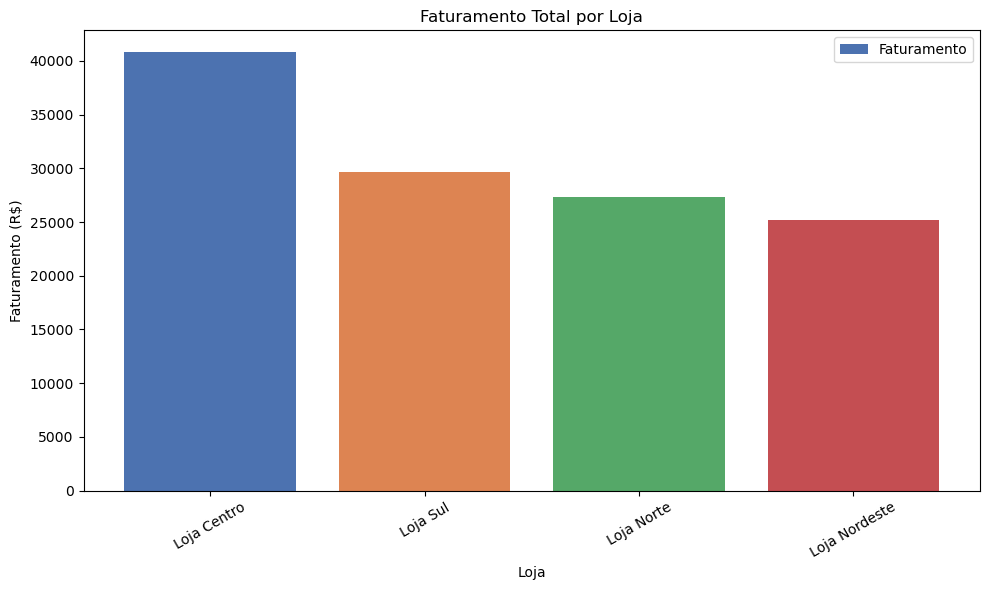

In [26]:
os.makedirs("graficos", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.bar(
    faturamento_loja.index,
    faturamento_loja.values,
    color=sns.color_palette("deep", len(faturamento_loja)),
    label="Faturamento"
)
plt.title("Faturamento Total por Loja")
plt.xlabel("Loja")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig("graficos/faturamento_por_loja.png", dpi=300)
plt.show()

## Questão 12

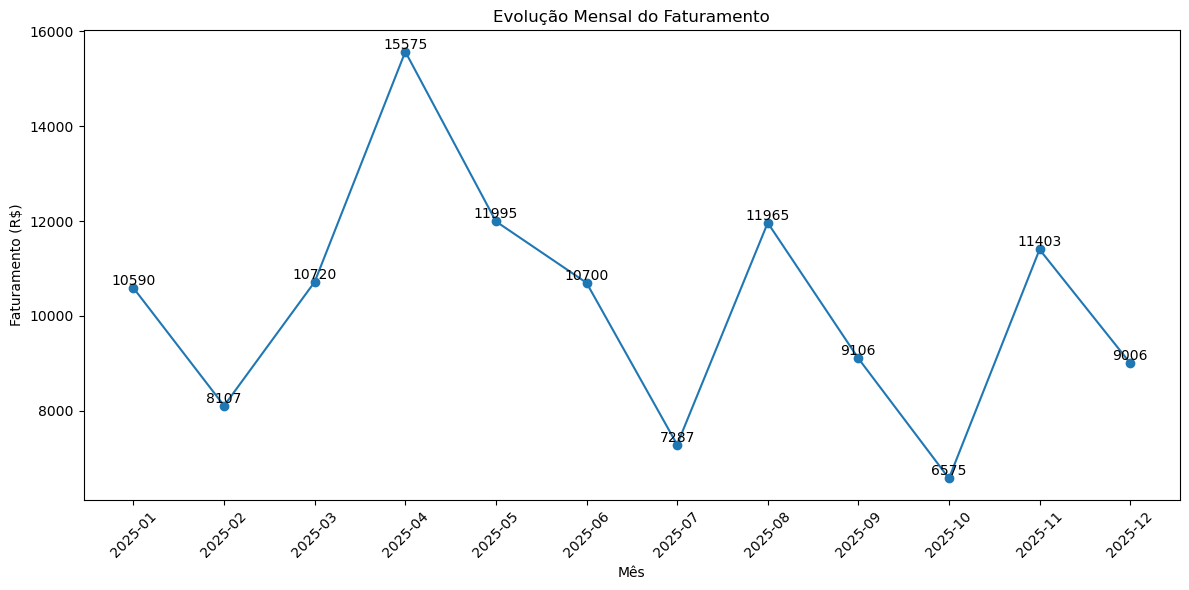

In [27]:
x = faturamento_mensal.index.astype(str)
y = faturamento_mensal.values

plt.figure(figsize=(12, 6))
plt.plot(x, y, marker="o")

for i, valor in enumerate(y):
    plt.text(i, valor, f"{valor:.0f}", ha="center", va="bottom")

plt.title("Evolução Mensal do Faturamento")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/evolucao_mensal.png", dpi=300)
plt.show()

## Questão 13

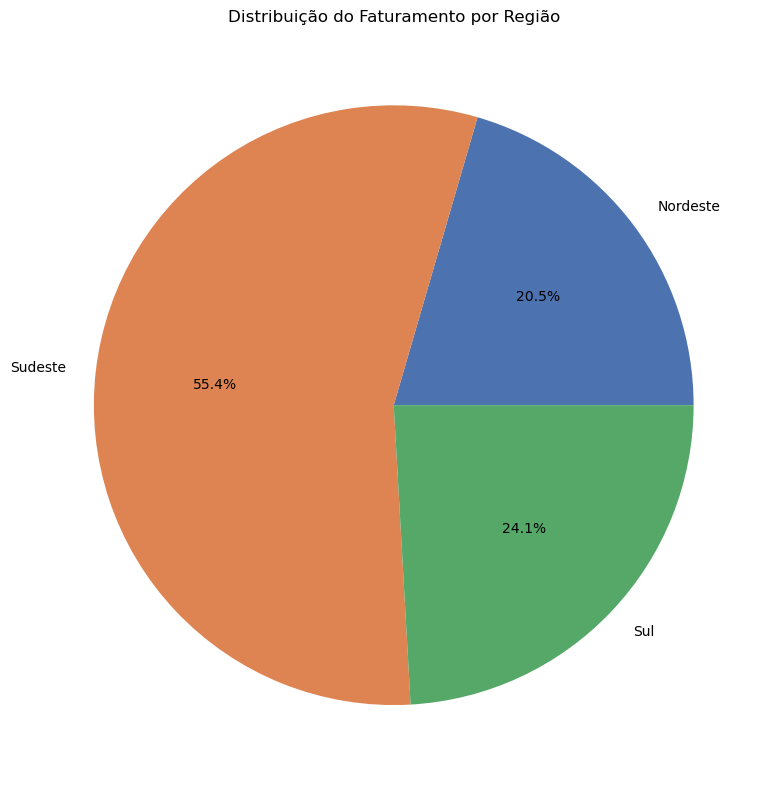

In [28]:
faturamento_regiao = df.groupby("regiao")["faturamento"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    faturamento_regiao.values,
    labels=faturamento_regiao.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("deep", len(faturamento_regiao))
)
plt.title("Distribuição do Faturamento por Região")
plt.tight_layout()
plt.savefig("graficos/faturamento_por_regiao.png", dpi=300)
plt.show()

## Questão 14

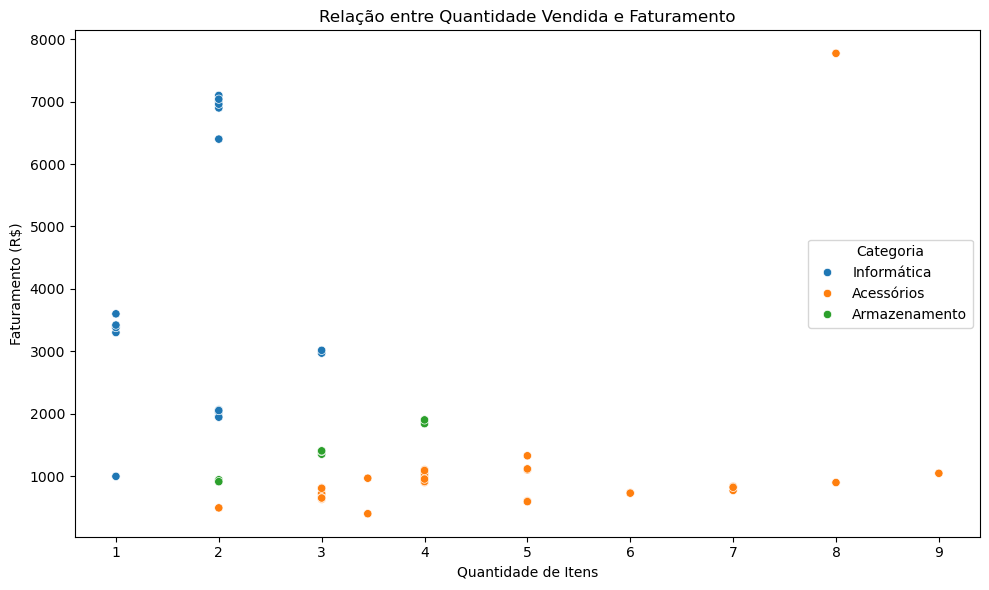

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="quantidade",
    y="faturamento",
    hue="categoria"
)
plt.title("Relação entre Quantidade Vendida e Faturamento")
plt.xlabel("Quantidade de Itens")
plt.ylabel("Faturamento (R$)")
plt.legend(title="Categoria")
plt.tight_layout()
plt.savefig("graficos/scatter_quantidade_faturamento.png", dpi=300)
plt.show()

## Questão 15

/tmp/ipykernel_13524/2895490577.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Categoria")


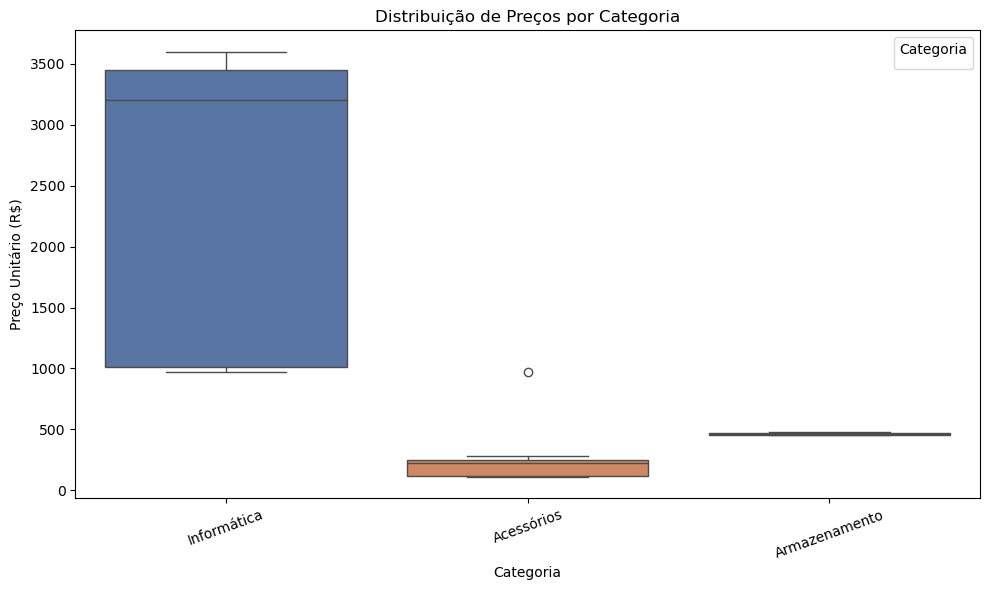

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="categoria",
    y="preco_unitario",
    hue="categoria",
    palette="deep"
)
plt.title("Distribuição de Preços por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Preço Unitário (R$)")
plt.xticks(rotation=20)
plt.legend(title="Categoria")
plt.tight_layout()
plt.savefig("graficos/boxplot_precos_categoria.png", dpi=300)
plt.show()

## Questão 16

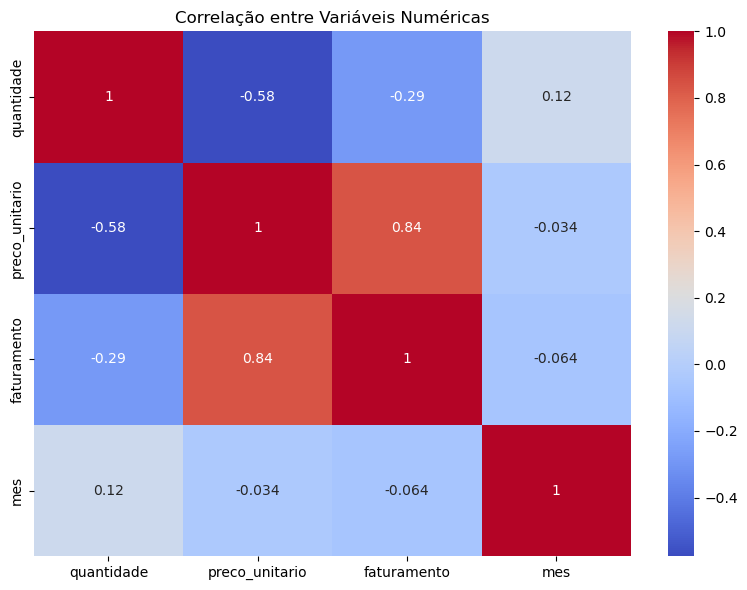

In [31]:
correlacao = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.savefig("graficos/heatmap_correlacao.png", dpi=300)
plt.show()

## Questão 17

In [32]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("deep"))

## Questão 18

In [33]:
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9

## Questão 19

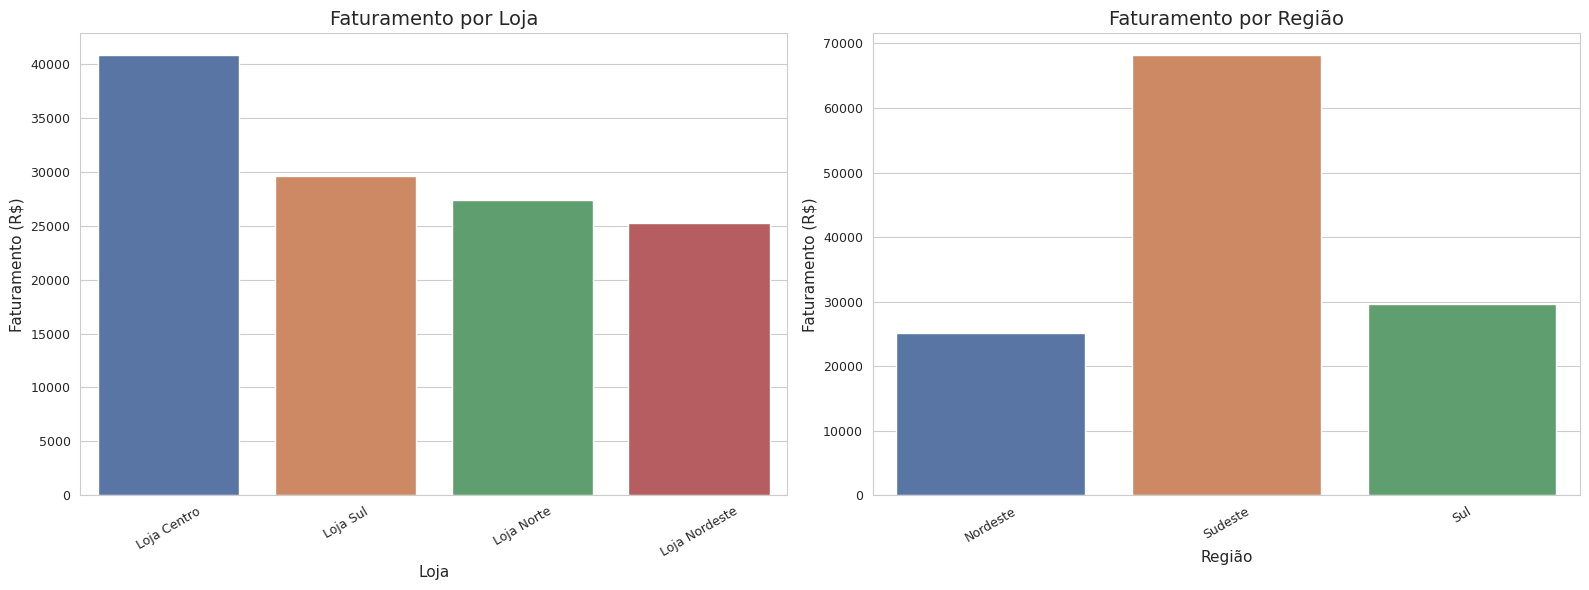

In [34]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(
    x=faturamento_loja.index,
    y=faturamento_loja.values,
    hue=faturamento_loja.index,
    palette="deep",
    legend=False
)
plt.title("Faturamento por Loja")
plt.xlabel("Loja")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=30)

plt.subplot(1, 2, 2)
sns.barplot(
    x=faturamento_regiao.index,
    y=faturamento_regiao.values,
    hue=faturamento_regiao.index,
    palette="deep",
    legend=False
)
plt.title("Faturamento por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("graficos/comparacao_loja_regiao.png", dpi=300)
plt.show()

## Questão 20

In [35]:
loja_maior_faturamento = faturamento_loja.idxmax()
loja_maior_ticket = ticket_medio.idxmax()
produto_mais_vendido = produtos_mais_vendidos.idxmax()
regiao_maior_faturamento = faturamento_regiao.idxmax()

resumo = pd.DataFrame({
    "indicador": [
        "Faturamento total",
        "Loja com maior faturamento",
        "Valor do maior faturamento por loja",
        "Loja com maior ticket médio",
        "Maior ticket médio",
        "Produto mais vendido",
        "Quantidade do produto mais vendido",
        "Mês com maior faturamento",
        "Valor do maior faturamento mensal",
        "Mês com menor faturamento",
        "Valor do menor faturamento mensal",
        "Região com maior faturamento",
        "Valor do maior faturamento regional"
    ],
    "resultado": [
        round(df["faturamento"].sum(), 2),
        loja_maior_faturamento,
        round(faturamento_loja.max(), 2),
        loja_maior_ticket,
        round(ticket_medio.max(), 2),
        produto_mais_vendido,
        round(produtos_mais_vendidos.max(), 2),
        maior_mes.strftime("%m/%Y"),
        round(faturamento_mensal.max(), 2),
        menor_mes.strftime("%m/%Y"),
        round(faturamento_mensal.min(), 2),
        regiao_maior_faturamento,
        round(faturamento_regiao.max(), 2)
    ]
})

resumo.to_csv("resumo_analitico.csv", index=False)
resumo

,indicador,resultado
0,Faturamento total,123027.34
1,Loja com maior faturamento,Loja Centro
2,Valor do maior faturamento por loja,40798.28
3,Loja com maior ticket médio,Loja Centro
4,Maior ticket médio,2549.89
5,Produto mais vendido,Mouse
6,Quantidade do produto mais vendido,71.45
7,Mês com maior faturamento,04/2025
8,Valor do maior faturamento mensal,15574.62
9,Mês com menor faturamento,10/2025


In [36]:
correlacao_faturamento = (
    correlacao["faturamento"]
    .drop("faturamento")
    .abs()
    .idxmax()
)

print("A loja com maior faturamento foi", loja_maior_faturamento)
print("O produto mais vendido foi", produto_mais_vendido)
print("A região com maior faturamento foi", regiao_maior_faturamento)
print("No gráfico de dispersão, a categoria Informática concentra os maiores valores de faturamento.")
print("No boxplot, Informática apresenta os maiores preços unitários.")
print("No heatmap, a variável mais relacionada ao faturamento foi", correlacao_faturamento)

A loja com maior faturamento foi Loja Centro
O produto mais vendido foi Mouse
A região com maior faturamento foi Sudeste
No gráfico de dispersão, a categoria Informática concentra os maiores valores de faturamento.
No boxplot, Informática apresenta os maiores preços unitários.
No heatmap, a variável mais relacionada ao faturamento foi preco_unitario
